In [1]:
# Oasis Infobyte Data Analytics Internship
# Level 1 - Task 4: Sentiment Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("Tweets.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

EmptyDataError: No columns to parse from file

In [4]:
import os

print("File size:", os.path.getsize("Tweets.csv"), "bytes")

File size: 0 bytes


In [1]:
df = pd.read_csv("Tweets.csv")

NameError: name 'pd' is not defined

In [2]:
df = pd.read_csv("Tweets.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

NameError: name 'pd' is not defined

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("Tweets.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (14640, 15)


In [5]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [6]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [7]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [9]:
df.duplicated().sum()

np.int64(36)

In [10]:
df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("New shape:", df.shape)

Duplicates removed successfully!
New shape: (14604, 15)


In [11]:
print(df['text'].head())

0                  @VirginAmerica What @dhepburn said.
1    @VirginAmerica plus you've added commercials t...
2    @VirginAmerica I didn't today... Must mean I n...
3    @VirginAmerica it's really aggressive to blast...
4    @VirginAmerica and it's a really big bad thing...
Name: text, dtype: object


In [12]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [13]:
df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                          clean_text  
0                                          what said  
1  plus youve added commercials to the experience...  
2  i didnt today must mean i need to take another...  
3  its really aggressive to blast obnoxious enter...  
4            and its a really big bad thing about it  


In [14]:
empty_texts = (df['clean_text'].str.strip() == '').sum()

print("Empty cleaned texts:", empty_texts)

Empty cleaned texts: 0


In [15]:
df = df[df['clean_text'].str.strip() != ''].copy()

print("Shape after text cleaning:", df.shape)

Shape after text cleaning: (14604, 16)


In [16]:
sentiment_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['sentiment_label'] = df['airline_sentiment'].map(sentiment_mapping)

print(df[['airline_sentiment', 'sentiment_label']].head())

  airline_sentiment  sentiment_label
0           neutral                1
1          positive                2
2           neutral                1
3          negative                0
4          negative                0


In [17]:
X = df['clean_text']
y = df['sentiment_label']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (14604,)
Target: (14604,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

NameError: name 'train_test_split' is not defined

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 11683
Testing samples: 2921


In [21]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

NameError: name 'TfidfVectorizer' is not defined

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (11683, 5000)
Testing TF-IDF shape: (2921, 5000)


### TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that can be used by machine learning models. It gives higher importance to words that are frequent in a particular document but less common across the entire dataset. This helps the model identify words that are more useful for distinguishing between negative, neutral, and positive sentiments.

In [24]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully!")

NameError: name 'MultinomialNB' is not defined

In [25]:

from sklearn.naive_bayes import MultinomialNB

In [26]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [27]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, average='weighted')
nb_recall = recall_score(y_test, nb_predictions, average='weighted')
nb_f1 = f1_score(y_test, nb_predictions, average='weighted')

print("Naive Bayes Performance")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))

NameError: name 'accuracy_score' is not defined

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [29]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, average='weighted')
nb_recall = recall_score(y_test, nb_predictions, average='weighted')
nb_f1 = f1_score(y_test, nb_predictions, average='weighted')

print("Naive Bayes Performance")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))

Naive Bayes Performance
Accuracy : 0.7155
Precision: 0.7293
Recall   : 0.7155
F1-Score : 0.662


In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [31]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions, average='weighted')
lr_recall = recall_score(y_test, lr_predictions, average='weighted')
lr_f1 = f1_score(y_test, lr_predictions, average='weighted')

print("Logistic Regression Performance")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))

Logistic Regression Performance
Accuracy : 0.7651
Precision: 0.7535
Recall   : 0.7651
F1-Score : 0.7477


In [32]:
comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_accuracy, lr_accuracy],
    'Precision': [nb_precision, lr_precision],
    'Recall': [nb_recall, lr_recall],
    'F1-Score': [nb_f1, lr_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.715508,0.729317,0.715508,0.661991
1,Logistic Regression,0.765149,0.753476,0.765149,0.747660


In [33]:
from sklearn.metrics import confusion_matrix

nb_cm = confusion_matrix(y_test, nb_predictions)

print("Naive Bayes Confusion Matrix:")
print(nb_cm)

Naive Bayes Confusion Matrix:
[[1802   24    6]
 [ 470  130   18]
 [ 279   34  158]]


In [34]:
lr_cm = confusion_matrix(y_test, lr_predictions)

print("Logistic Regression Confusion Matrix:")
print(lr_cm)

Logistic Regression Confusion Matrix:
[[1716   80   36]
 [ 325  257   36]
 [ 136   73  262]]


In [35]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

NameError: name 'plt' is not defined

In [36]:
import matplotlib.pyplot as plt

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

NameError: name 'sns' is not defined

<Figure size 600x500 with 0 Axes>

In [38]:
import seaborn as sns

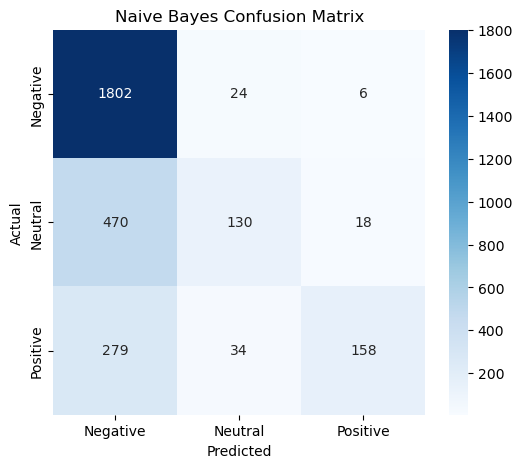

In [39]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

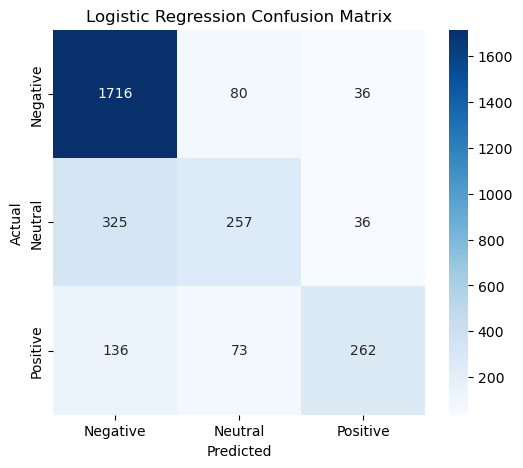

In [40]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

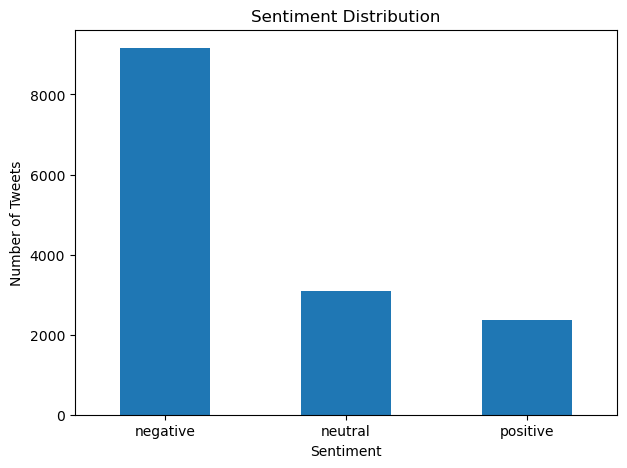

In [41]:
sentiment_counts = df['airline_sentiment'].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.reindex(['negative', 'neutral', 'positive']).plot(kind='bar')

plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.title('Sentiment Distribution')
plt.xticks(rotation=0)
plt.show()

In [42]:
from wordcloud import WordCloud

ModuleNotFoundError: No module named 'wordcloud'

In [43]:
from wordcloud import WordCloud

ModuleNotFoundError: No module named 'wordcloud'

In [44]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [45]:
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [46]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [1]:
from wordcloud import WordCloud

In [2]:
negative_text = " ".join(
    df[df['airline_sentiment'] == 'negative']['text'].astype(str)
)

negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Sentiment WordCloud')
plt.show()

NameError: name 'df' is not defined

In [3]:
import pandas as pd

df = pd.read_csv("Tweets.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (14640, 15)


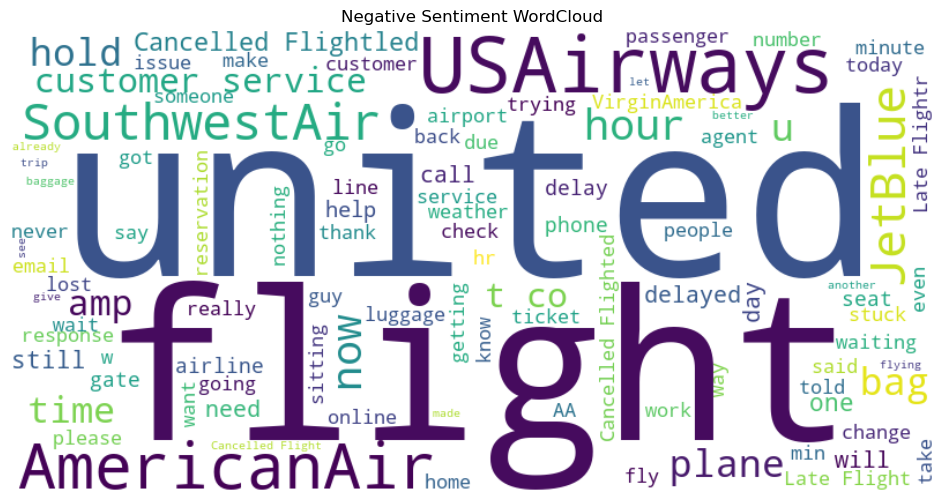

In [4]:
import matplotlib.pyplot as plt

negative_text = " ".join(
    df[df['airline_sentiment'] == 'negative']['text'].astype(str)
)

negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Sentiment WordCloud')
plt.show()

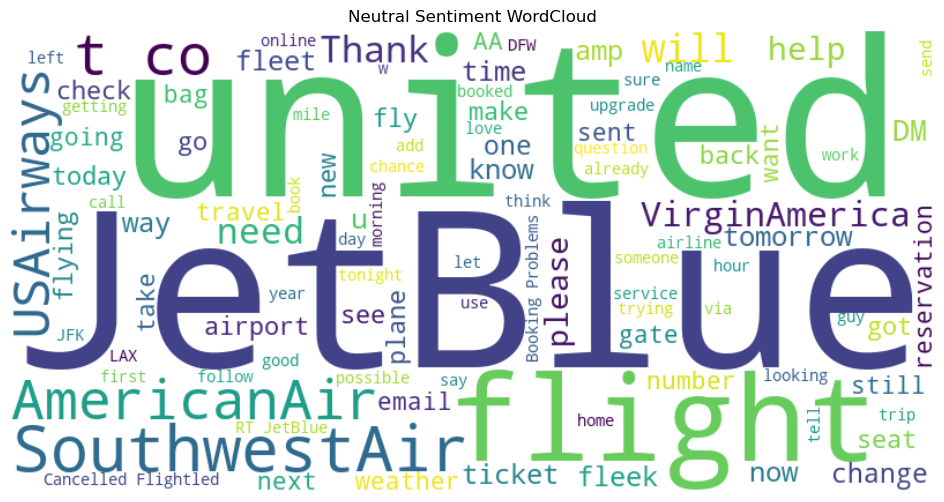

In [5]:
neutral_text = " ".join(
    df[df['airline_sentiment'] == 'neutral']['text'].astype(str)
)

neutral_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(neutral_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Neutral Sentiment WordCloud')
plt.show()

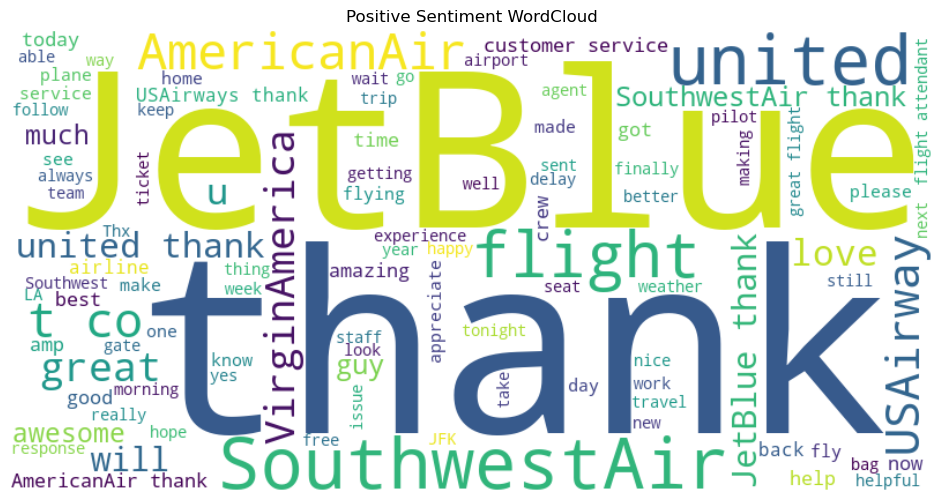

In [6]:
positive_text = " ".join(
    df[df['airline_sentiment'] == 'positive']['text'].astype(str)
)

positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Sentiment WordCloud')
plt.show()

In [7]:
error_analysis = pd.DataFrame({
    'Text': X_test,
    'Actual': y_test,
    'Predicted': lr_predictions
})

misclassified = error_analysis[
    error_analysis['Actual'] != error_analysis['Predicted']
]

misclassified.head(5)

NameError: name 'X_test' is not defined

In [8]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 11712
Testing samples: 2928


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (11712, 5000)
Testing TF-IDF shape: (2928, 5000)


In [10]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [11]:
error_analysis = pd.DataFrame({
    'Text': X_test,
    'Actual': y_test,
    'Predicted': lr_predictions
})

misclassified = error_analysis[
    error_analysis['Actual'] != error_analysis['Predicted']
]

misclassified.head(5)

,Text,Actual,Predicted
2998,@united past,neutral,negative
7719,@JetBlue would you say a delay is more likely?...,positive,negative
4006,@united This link in your tweet goes to someon...,neutral,negative
3838,@united of course but they were just as helple...,negative,neutral
8985,@USAirways Well I did miss it. But gate agents...,positive,negative


### Error Analysis

The model misclassified some tweets because sentiment can be difficult to identify from text alone. Common reasons include sarcasm, unclear wording, short messages, mixed emotions, and words that can have different meanings depending on context. These examples show that even a trained sentiment classifier can make mistakes when the meaning of a tweet is ambiguous.

In [12]:
print("Naive Bayes F1-Score:", round(nb_f1, 4))
print("Logistic Regression F1-Score:", round(lr_f1, 4))

NameError: name 'nb_f1' is not defined

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions, average='weighted')
lr_recall = recall_score(y_test, lr_predictions, average='weighted')
lr_f1 = f1_score(y_test, lr_predictions, average='weighted')

print("Logistic Regression Performance")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))

Logistic Regression Performance
Accuracy : 0.7824
Precision: 0.7741
Recall   : 0.7824
F1-Score : 0.7695


In [14]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, average='weighted')
nb_recall = recall_score(y_test, nb_predictions, average='weighted')
nb_f1 = f1_score(y_test, nb_predictions, average='weighted')

print("Naive Bayes Performance")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))

Naive Bayes Performance
Accuracy : 0.7227
Precision: 0.7418
Recall   : 0.7227
F1-Score : 0.6719


In [15]:
comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_accuracy, lr_accuracy],
    'Precision': [nb_precision, lr_precision],
    'Recall': [nb_recall, lr_recall],
    'F1-Score': [nb_f1, lr_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.722678,0.741820,0.722678,0.671915
1,Logistic Regression,0.782445,0.774139,0.782445,0.769532


## Conclusion

Two machine learning models, Naive Bayes and Logistic Regression, were trained to classify tweets into negative, neutral, and positive sentiments using TF-IDF features.

Based on the evaluation metrics, the model with the higher F1-score performed better on this dataset. The sentiment analysis model can be useful for monitoring customer feedback, identifying common customer concerns, and understanding public opinion about services or products.

# Oasis Infobyte Data Analytics Internship
## Level 1 - Task 4: Sentiment Analysis

### Objective

The objective of this project is to build a machine learning model that classifies text into positive, negative, or neutral sentiment and provides insights into customer feedback and public opinion.

### Dataset

The Twitter US Airline Sentiment dataset contains tweets with sentiment labels such as negative, neutral, and positive.

### Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- NLTK/Text Processing
- Matplotlib
- Seaborn
- WordCloud
- Jupyter Notebook

## 1. Dataset Overview and Sentiment Distribution

The dataset contains tweets related to airline services. The sentiment classes are negative, neutral, and positive.

The original dataset contains:

- Negative: 9,178 tweets
- Neutral: 3,099 tweets
- Positive: 2,363 tweets

After removing 36 duplicate rows, 14,604 records remained for analysis.

## 2. Text Preprocessing

The tweet text was cleaned before applying machine learning techniques.

The preprocessing steps included:

- Converting text to lowercase
- Removing URLs
- Removing @mentions
- Removing hashtags
- Removing punctuation and numbers
- Removing extra spaces
- Removing empty cleaned text entries

## 2. Text Preprocessing

The tweet text was cleaned before applying machine learning techniques.

The preprocessing steps included:

- Converting text to lowercase
- Removing URLs
- Removing @mentions
- Removing hashtags
- Removing punctuation and numbers
- Removing extra spaces
- Removing empty cleaned text entries

## 3. TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) was used to convert the cleaned tweet text into numerical features.

TF-IDF gives more importance to words that are useful for distinguishing documents while reducing the importance of words that appear frequently across many documents.

A maximum of 5,000 features was used for the machine learning models.

## 4. Machine Learning Models and Evaluation

Two classification algorithms were trained:

- **Multinomial Naive Bayes**
- **Logistic Regression**

Both models were trained using the TF-IDF features and evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

The evaluation results were compared to understand the performance of the two models on the sentiment classification task.

## 5. Visualization and Error Analysis

The sentiment distribution was visualized using a bar chart.

WordCloud visualizations were created separately for:

- Negative sentiment
- Neutral sentiment
- Positive sentiment

A confusion matrix was created for both machine learning models to understand their classification performance.

Five misclassified examples were also examined to understand possible reasons for incorrect predictions, such as ambiguous wording, mixed emotions, short text, and sarcasm.